# Introduction to Neural Networks with PyTorch

In this notebook we build a **Multi-Layer Perceptron (MLP)** from scratch using PyTorch to classify wine quality from chemical measurements. This covers the essential PyTorch workflow:

1. **Tensors and autograd** — the backbone of PyTorch.
2. **Defining a model** — `nn.Module` and `nn.Sequential`.
3. **Choosing a loss and optimizer** — cross-entropy + Adam.
4. **The training loop** — forward pass, loss, backpropagation, update.
5. **Evaluation** — accuracy on held-out data, comparison with logistic regression.

**Dataset:** UCI Wine Quality (red wine). Each sample has 11 physicochemical features (e.g. alcohol, pH, sulphates) and a quality score from 3 to 8. We turn this into a binary classification task: *good* (quality ≥ 6) vs *not good* (quality < 6).

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.10.0


---
## Part 1: Tensors and Autograd

A `torch.Tensor` is an N-dimensional array similar to a NumPy array, but with two key superpowers:
- It can live on the **GPU**.
- It tracks operations for **automatic differentiation** (autograd).

In [2]:
# --- 1.1 Creating tensors ---
x = torch.tensor([1.0, 2.0, 3.0])
print("Tensor:      ", x)
print("Shape:       ", x.shape)
print("dtype:       ", x.dtype)
print("Device:      ", x.device)

# From NumPy (zero-copy)
arr = np.array([4.0, 5.0, 6.0])
t = torch.from_numpy(arr)
print("\nFrom NumPy:  ", t)

Tensor:       tensor([1., 2., 3.])
Shape:        torch.Size([3])
dtype:        torch.float32
Device:       cpu

From NumPy:   tensor([4., 5., 6.], dtype=torch.float64)


In [3]:
# --- 1.2 Autograd: automatic differentiation ---
# Suppose we want d/dx (x^2 + 2x) at x = 3.
x = torch.tensor(3.0, requires_grad=True)  # tell PyTorch to track this variable

y = x**2 + 2*x        # build a computation graph
y.backward()           # compute dy/dx via backpropagation

print(f"y = x^2 + 2x at x=3  →  y = {y.item():.1f}")
print(f"dy/dx = 2x + 2 at x=3  →  grad = {x.grad.item():.1f}")   # expected: 8

y = x^2 + 2x at x=3  →  y = 15.0
dy/dx = 2x + 2 at x=3  →  grad = 8.0


Autograd works on arbitrary computation graphs — including entire neural networks. Calling `.backward()` on the loss automatically computes all the weight gradients needed for the update step.

---
## Part 2: Loading and Preparing the Data

We fetch the **UCI Red Wine Quality** dataset and turn it into a binary classification problem:
- **Positive class (1):** quality ≥ 6 (*good*)
- **Negative class (0):** quality < 6 (*not good*)

In [4]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=";")
print(df.shape)
df.head()

(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
# Binary target: good (quality >= 6) vs not good (quality < 6)
X = df.drop("quality", axis=1).values.astype(np.float32)
y = (df["quality"] >= 6).astype(np.int64).values

print("Features shape:", X.shape)
print("Class balance — good:", y.mean().round(3), "   not good:", (1 - y).mean().round(3))

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature standardisation (critical for neural networks!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")

Features shape: (1599, 11)
Class balance — good: 0.535    not good: 0.465

Train size: 1279, Test size: 320


In [6]:
# Convert NumPy arrays to PyTorch tensors
X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)
X_test_t  = torch.from_numpy(X_test)
y_test_t  = torch.from_numpy(y_test)

print("Tensor dtype — X:", X_train_t.dtype, "  y:", y_train_t.dtype)
print("Tensor shape — X:", X_train_t.shape, "  y:", y_train_t.shape)

Tensor dtype — X: torch.float32   y: torch.int64
Tensor shape — X: torch.Size([1279, 11])   y: torch.Size([1279])


---
## Part 3: Defining the Model

We define a small **MLP** with two hidden layers using `nn.Sequential`.

| Layer | Type | Output shape |
|-------|------|-------------|
| Input | — | `(batch, 11)` |
| `Linear(11, 64)` + `ReLU` | Fully connected | `(batch, 64)` |
| `Linear(64, 32)` + `ReLU` | Fully connected | `(batch, 32)` |
| `Linear(32, 2)` | Output (logits) | `(batch, 2)` |

The output is **two logits** (one per class). `nn.CrossEntropyLoss` will apply softmax internally.

In [7]:
n_features = X_train_t.shape[1]  # 11

model = nn.Sequential(
    nn.Linear(n_features, 64), nn.ReLU(),
    nn.Linear(64, 32),         nn.ReLU(),
    nn.Linear(32, 2)           # 2 output logits for binary classification
)

print(model)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in model.parameters()):,}")

Sequential(
  (0): Linear(in_features=11, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=2, bias=True)
)

Total trainable parameters: 2,914


---
## Part 4: The Training Loop

We train for a fixed number of **epochs**. At each epoch we:
1. Pass the entire training set through the model (forward pass).
2. Compute the cross-entropy loss.
3. Call `.backward()` to compute gradients.
4. Call `optimizer.step()` to update the weights.
5. Call `optimizer.zero_grad()` to clear the accumulated gradients before the next step.

In [8]:
loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs  = 200
train_losses = []

for epoch in range(num_epochs):
    model.train()                          # enable training mode

    optimizer.zero_grad()                  # 1. clear gradients
    logits = model(X_train_t)             # 2. forward pass  → shape (N, 2)
    loss   = loss_fn(logits, y_train_t)   # 3. compute loss
    loss.backward()                        # 4. backpropagation
    optimizer.step()                       # 5. update weights

    train_losses.append(loss.item())

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{num_epochs}  |  loss: {loss.item():.4f}")

print("\nTraining complete.")

Epoch  20/200  |  loss: 0.6247
Epoch  40/200  |  loss: 0.5419
Epoch  60/200  |  loss: 0.5042
Epoch  80/200  |  loss: 0.4840
Epoch 100/200  |  loss: 0.4703
Epoch 120/200  |  loss: 0.4590
Epoch 140/200  |  loss: 0.4483
Epoch 160/200  |  loss: 0.4368
Epoch 180/200  |  loss: 0.4245
Epoch 200/200  |  loss: 0.4113

Training complete.


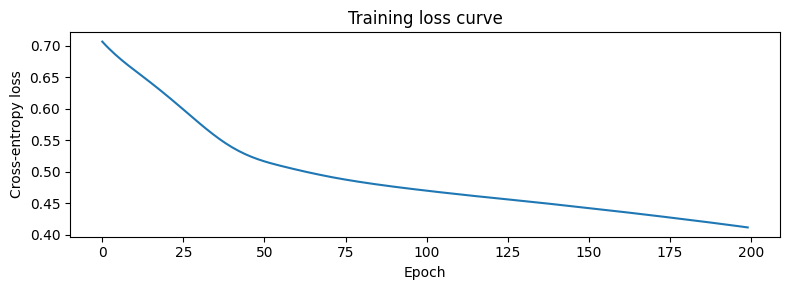

In [9]:
plt.figure(figsize=(8, 3))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training loss curve")
plt.tight_layout()
plt.show()

---
## Part 5: Evaluation

Switch the model to **evaluation mode** (`model.eval()`) and use `torch.no_grad()` to avoid building the computation graph (saves memory and compute).

In [10]:
model.eval()
with torch.no_grad():
    logits_test = model(X_test_t)              # shape (N_test, 2)
    preds_test  = logits_test.argmax(dim=1)    # predicted class

mlp_acc = (preds_test == y_test_t).float().mean().item()
print(f"MLP test accuracy: {mlp_acc:.3f}")

MLP test accuracy: 0.775


In [11]:
# Baseline: logistic regression with scikit-learn
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test))
print(f"Logistic Regression test accuracy: {lr_acc:.3f}")

# Summary
print(f"\n{'Model':<25} {'Accuracy':>10}")
print("-" * 36)
print(f"{'Logistic Regression':<25} {lr_acc:>10.3f}")
print(f"{'MLP (PyTorch)':<25} {mlp_acc:>10.3f}")

Logistic Regression test accuracy: 0.741

Model                       Accuracy
------------------------------------
Logistic Regression            0.741
MLP (PyTorch)                  0.775


---
## Part 6: Mini-Batch Training

The previous loop passed the **entire dataset** to the model at once. For larger datasets, we split the data into **mini-batches** using PyTorch's `DataLoader`.

In [12]:
from torch.utils.data import TensorDataset, DataLoader

# Wrap tensors in a Dataset
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Rebuild the model from scratch
model2 = nn.Sequential(
    nn.Linear(n_features, 64), nn.ReLU(),
    nn.Linear(64, 32),         nn.ReLU(),
    nn.Linear(32, 2)
)
optimizer2 = torch.optim.Adam(model2.parameters(), lr=1e-3)

num_epochs   = 50
epoch_losses = []

for epoch in range(num_epochs):
    model2.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        optimizer2.zero_grad()
        loss = loss_fn(model2(X_batch), y_batch)
        loss.backward()
        optimizer2.step()
        batch_losses.append(loss.item())
    epoch_losses.append(np.mean(batch_losses))

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:2d}/{num_epochs}  |  avg loss: {epoch_losses[-1]:.4f}")

# Evaluate
model2.eval()
with torch.no_grad():
    preds2 = model2(X_test_t).argmax(dim=1)

acc2 = (preds2 == y_test_t).float().mean().item()
print(f"\nMLP (mini-batch) test accuracy: {acc2:.3f}")

Epoch 10/50  |  avg loss: 0.4882
Epoch 20/50  |  avg loss: 0.4589
Epoch 30/50  |  avg loss: 0.4356
Epoch 40/50  |  avg loss: 0.4117
Epoch 50/50  |  avg loss: 0.3886

MLP (mini-batch) test accuracy: 0.778


---
## Part 7: Defining a Model with `nn.Module`

`nn.Sequential` is convenient but limited. For more control (e.g., skip connections, multiple inputs/outputs), subclass `nn.Module` directly.

In [13]:
class WineClassifier(nn.Module):
    def __init__(self, n_in: int, n_hidden: int, n_out: int, dropout: float = 0.3):
        super().__init__()
        self.fc1     = nn.Linear(n_in, n_hidden)
        self.fc2     = nn.Linear(n_hidden, n_hidden // 2)
        self.fc3     = nn.Linear(n_hidden // 2, n_out)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x   # raw logits


model3 = WineClassifier(n_in=n_features, n_hidden=64, n_out=2, dropout=0.3)
print(model3)

WineClassifier(
  (fc1): Linear(in_features=11, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


Final test accuracy: 0.772


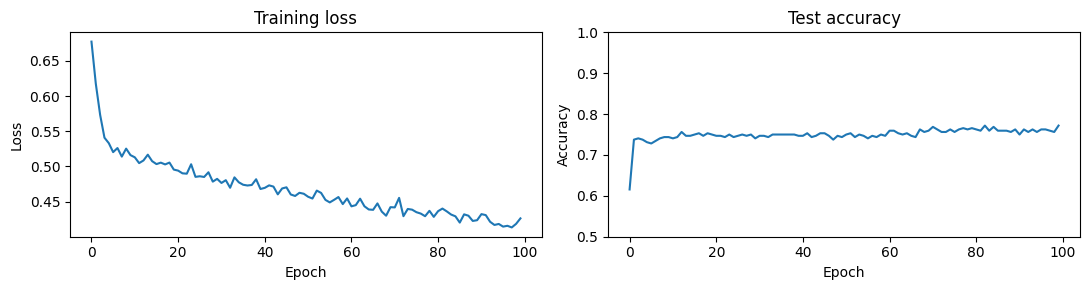

In [14]:
optimizer3 = torch.optim.Adam(model3.parameters(), lr=1e-3)

train_loss3, val_acc3 = [], []

for epoch in range(100):
    model3.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        optimizer3.zero_grad()
        loss = loss_fn(model3(X_batch), y_batch)
        loss.backward()
        optimizer3.step()
        batch_losses.append(loss.item())
    train_loss3.append(np.mean(batch_losses))

    model3.eval()
    with torch.no_grad():
        preds3 = model3(X_test_t).argmax(dim=1)
    val_acc3.append((preds3 == y_test_t).float().mean().item())

print(f"Final test accuracy: {val_acc3[-1]:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3))
ax1.plot(train_loss3); ax1.set(xlabel="Epoch", ylabel="Loss",     title="Training loss")
ax2.plot(val_acc3);    ax2.set(xlabel="Epoch", ylabel="Accuracy", title="Test accuracy",
                                ylim=(0.5, 1.0))
fig.tight_layout()
plt.show()